# Aurora Finance — Step 4: Derivatives Module
**Objective:** Hedge portfolio risk and price derivative exposures using ML.

**Real Data:** NSE NIFTY Intraday Option Chain — 2 February 2024  
**Source file:** `Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx`



## Section 1: Setup & Imports

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RISK_FREE_RATE = 0.065   # RBI repo rate, Feb 2024
CONTRACT_LOT   = 50      # NIFTY lot size
print('Libraries loaded. Risk-free rate:', RISK_FREE_RATE, '| Lot size:', CONTRACT_LOT)

Libraries loaded. Risk-free rate: 0.065 | Lot size: 50


## Section 2: Data Loading & Feature Engineering

In [37]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Abcom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [38]:
# from google.colab import drive
# drive.mount('/content/drive')

raw = pd.read_excel('..\\data\\Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx')
print(f'Raw shape: {raw.shape}')
print(f'Columns: {raw.columns.tolist()}')
raw.head(3)

Raw shape: (39485, 18)
Columns: ['Time', 'Spot', 'Expiry', 'Call_Traded_Qty', 'Call IV', 'Call Bid', 'Call Ask', 'Call Bid_Qty', 'Call Ask_Qty', 'Call LTP', 'Strike', 'Put Bid', 'Put Ask', 'Put Bid_Qty', 'Put Ask_Qty', 'Put LTP', 'Put IV', 'Put_Traded_Qty']


,Time,Spot,Expiry,Call_Traded_Qty,Call IV,Call Bid,Call Ask,Call Bid_Qty,Call Ask_Qty,Call LTP,Strike,Put Bid,Put Ask,Put Bid_Qty,Put Ask_Qty,Put LTP,Put IV,Put_Traded_Qty
0,2024-02-02 09:20:00,21874.4000,2024-02-08,0,0.0000,2173.2000,2656.2000,150,100,0.0000,19500,1.3500,1.4000,21350,67650,1.4000,35.1600,4297
1,2024-02-02 09:25:00,21935.7000,2024-02-08,0,0.0000,2218.9000,2612.3000,1500,1500,0.0000,19500,1.3500,1.4000,21300,47250,1.3500,35.6400,10098
2,2024-02-02 09:30:00,21942.5000,2024-02-08,0,0.0000,2231.1000,2601.2500,1500,1000,0.0000,19500,1.3500,1.4000,66600,33500,1.4000,35.8900,13128


In [39]:
# ── Reshape: each row has both Call & Put this is wide format and hence we consolidate to one option per row ──
calls = raw[['Time','Spot','Expiry','Strike','Call LTP','Call IV',
             'Call Bid','Call Ask','Call_Traded_Qty']].copy()
calls.columns = ['Time','Spot','Expiry','Strike','Market_Price','IV',
                 'Bid','Ask','Traded_Qty']
calls['Option_Type'] = 'Call'

puts = raw[['Time','Spot','Expiry','Strike','Put LTP','Put IV',
            'Put Bid','Put Ask','Put_Traded_Qty']].copy()
puts.columns = ['Time','Spot','Expiry','Strike','Market_Price','IV',
                'Bid','Ask','Traded_Qty']
puts['Option_Type'] = 'Put'

df = pd.concat([calls, puts], ignore_index=True)

# ── Clean: drop zero-price rows (illiquid / no-trade contracts so cannot compute IV) ──
df = df[df['Market_Price'] > 0].reset_index(drop=True)

# ── Constants ─────────────────────────────────────────────────────
RISK_FREE_RATE = 0.065          # RBI repo rate ~6.5% annualised
VALUATION_DATE = pd.Timestamp('2024-02-02')

print(f'Long-format shape: {df.shape}')
print(f'Option types: {df["Option_Type"].value_counts().to_dict()}')
print(f'Unique strikes: {df["Strike"].nunique()}')
print(f'Expiry dates: {sorted(df["Expiry"].unique())}')
df.head()

Long-format shape: (48724, 10)
Option types: {'Put': 24449, 'Call': 24275}
Unique strikes: 107
Expiry dates: [Timestamp('2024-02-08 00:00:00'), Timestamp('2024-02-15 00:00:00'), Timestamp('2024-02-22 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-03-07 00:00:00'), Timestamp('2024-03-28 00:00:00')]


,Time,Spot,Expiry,Strike,Market_Price,IV,Bid,Ask,Traded_Qty,Option_Type
0,2024-02-02 09:55:00,21939.4000,2024-02-08,19500,2279.0000,0.0000,2488.7500,2538.5500,1,Call
1,2024-02-02 10:00:00,21924.1000,2024-02-08,19500,2279.0000,0.0000,2452.3500,2531.0000,1,Call
2,2024-02-02 10:05:00,21936.6000,2024-02-08,19500,2279.0000,0.0000,2452.4000,2537.6000,1,Call
3,2024-02-02 10:10:00,21936.7500,2024-02-08,19500,2279.0000,0.0000,2452.5000,2508.1500,1,Call
4,2024-02-02 10:15:00,21940.0000,2024-02-08,19500,2279.0000,0.0000,2452.5000,2548.6500,1,Call


**Section 3: Exploratory Data Analysis**

In [40]:
print('=== Basic Statistics ===')
print(df[['Market_Price','IV','Spot','Strike','Traded_Qty']].describe().round(2))

=== Basic Statistics ===
       Market_Price         IV       Spot     Strike   Traded_Qty
count    48724.0000 48724.0000 48724.0000 48724.0000   48724.0000
mean       444.5500    14.1000 21929.0400 21714.1300   48935.7100
std        720.1300     7.9900    76.5100  1368.8600  190334.6800
min          0.6500     0.0000 21816.2000 14000.0000       1.0000
25%         22.4500    12.4200 21873.1000 20900.0000      64.0000
50%        159.1500    14.5600 21921.4000 21800.0000     848.0000
75%        580.0000    17.0900 21944.2500 22650.0000    8793.2500
max       8149.3500   100.7800 22122.6000 27000.0000 3018735.0000


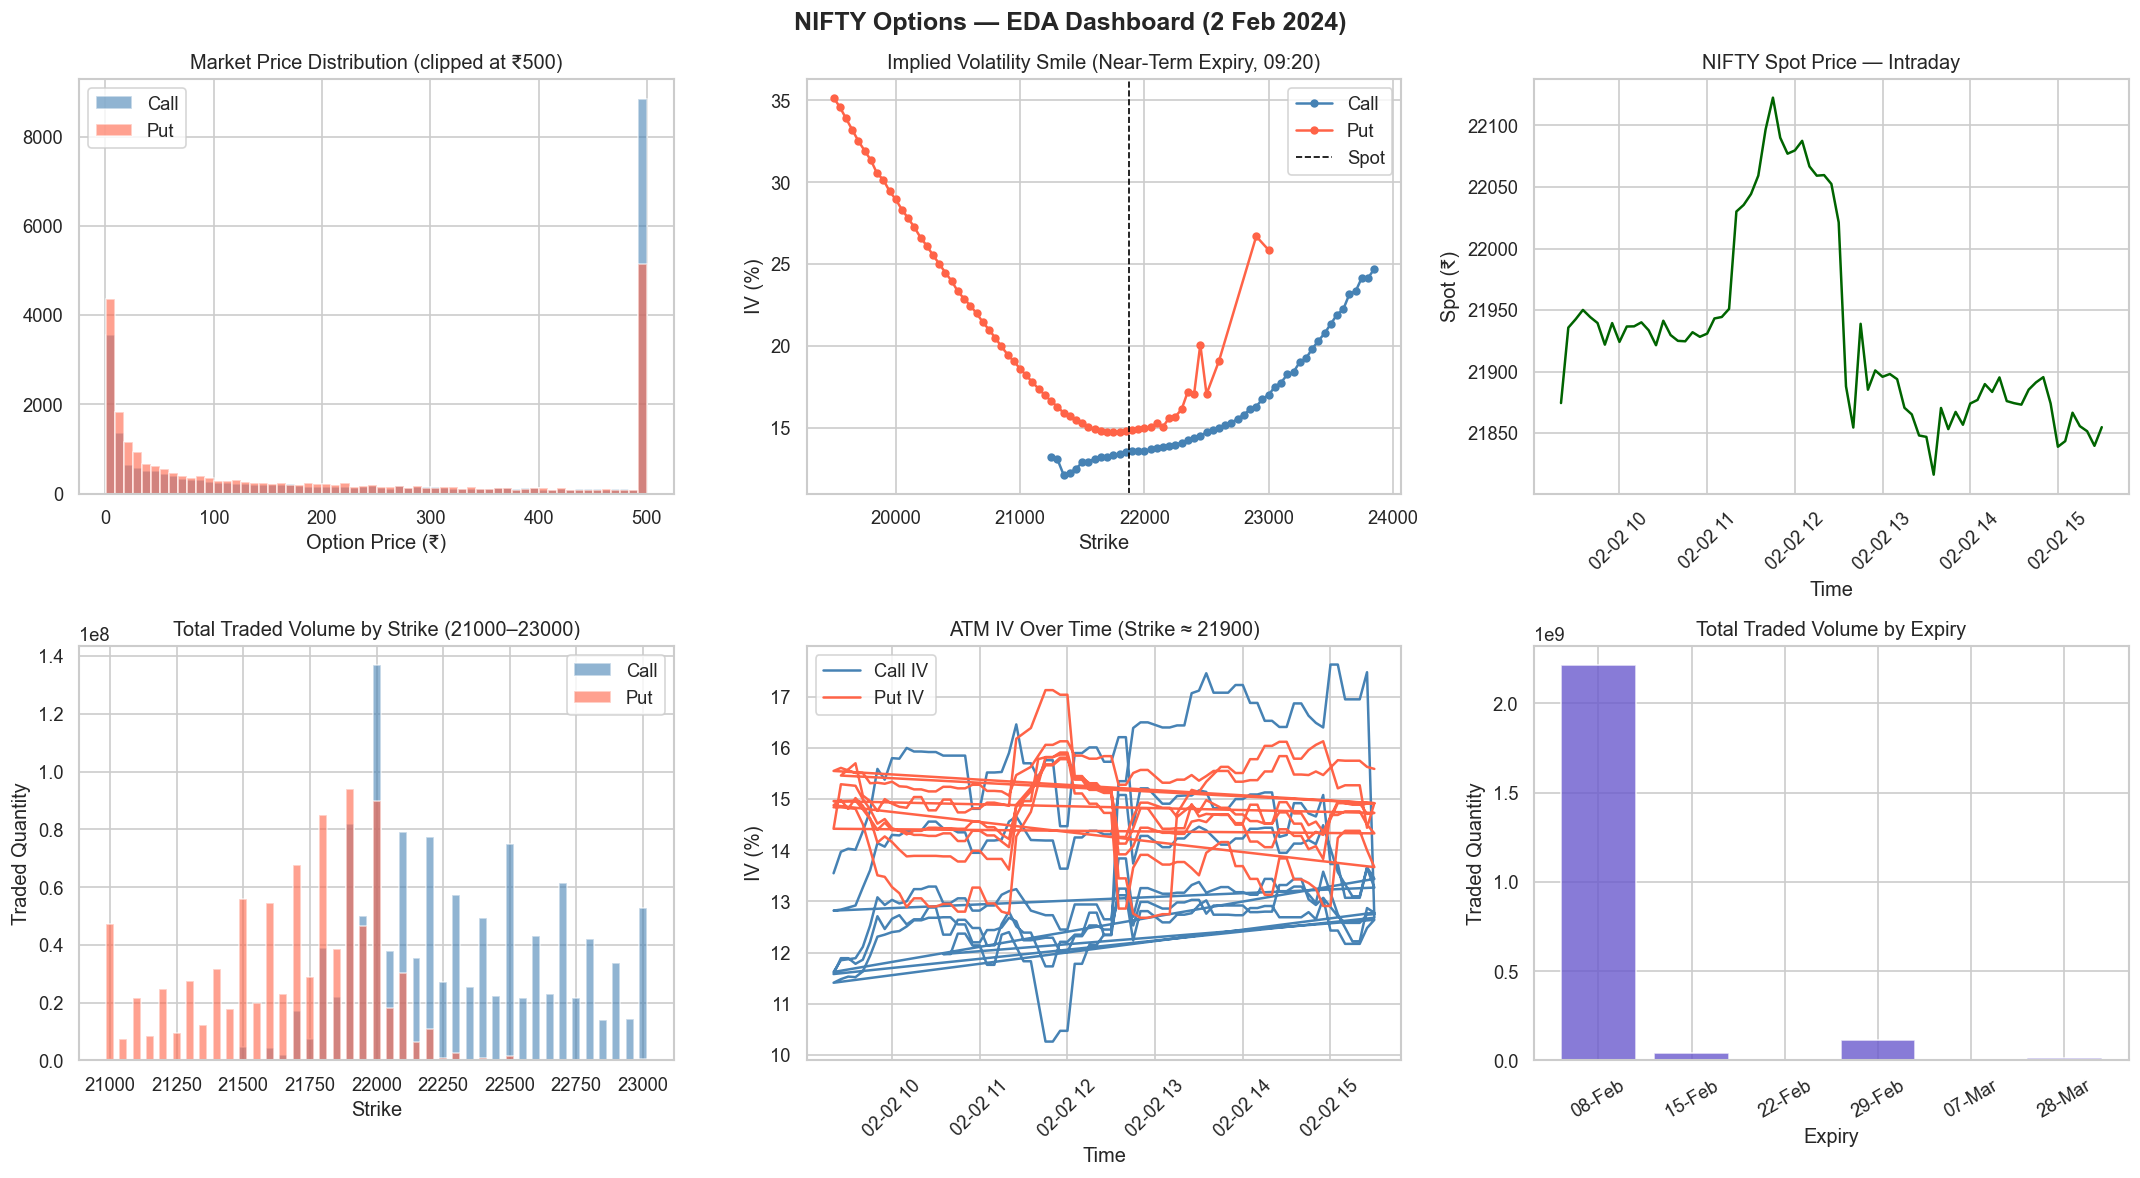

<Figure size 768x576 with 0 Axes>

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NIFTY Options — EDA Dashboard (2 Feb 2024)', fontsize=15, fontweight='bold')

# 1. Market Price distribution by type
for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    subset = df[df['Option_Type'] == otype]['Market_Price']
    axes[0,0].hist(subset.clip(upper=500), bins=60, alpha=0.6, color=color, label=otype)
axes[0,0].set_title('Market Price Distribution (clipped at ₹500)')
axes[0,0].set_xlabel('Option Price (₹)')
axes[0,0].legend()

# 2. IV smile — ATM snapshot (first timestamp, near-term expiry)
snap = df[(df['Time'] == df['Time'].min()) &
          (df['Expiry'] == df['Expiry'].min()) &
          (df['IV'] > 0) & (df['IV'] < 80)]
for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = snap[snap['Option_Type'] == otype].sort_values('Strike')
    axes[0,1].plot(s['Strike'], s['IV'], marker='o', ms=4, color=color, label=otype)
axes[0,1].axvline(snap['Spot'].iloc[0], color='black', linestyle='--', linewidth=1, label='Spot')
axes[0,1].set_title('Implied Volatility Smile (Near-Term Expiry, 09:20)')
axes[0,1].set_xlabel('Strike')
axes[0,1].set_ylabel('IV (%)')
axes[0,1].legend()

# 3. Spot price intraday
spot_ts = df.groupby('Time')['Spot'].first()
axes[0,2].plot(spot_ts.index, spot_ts.values, color='darkgreen', linewidth=1.5)
axes[0,2].set_title('NIFTY Spot Price — Intraday')
axes[0,2].set_xlabel('Time')
axes[0,2].set_ylabel('Spot (₹)')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Volume by strike (ATM focus)
vol_by_strike = df.groupby(['Strike','Option_Type'])['Traded_Qty'].sum().reset_index()
vol_by_strike = vol_by_strike[vol_by_strike['Strike'].between(21000, 23000)]
for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = vol_by_strike[vol_by_strike['Option_Type'] == otype]
    axes[1,0].bar(s['Strike'], s['Traded_Qty'], alpha=0.6, color=color, label=otype, width=30)
axes[1,0].set_title('Total Traded Volume by Strike (21000–23000)')
axes[1,0].set_xlabel('Strike')
axes[1,0].set_ylabel('Traded Quantity')
axes[1,0].legend()

# 5. IV over time (ATM contract)
atm_strike = df.groupby('Time')['Spot'].first().mean().round(-2)
atm_calls = df[(df['Strike'] == atm_strike) & (df['Option_Type'] == 'Call') & (df['IV'] > 0)]
atm_puts  = df[(df['Strike'] == atm_strike) & (df['Option_Type'] == 'Put')  & (df['IV'] > 0)]
axes[1,1].plot(atm_calls['Time'], atm_calls['IV'], color='steelblue', label='Call IV', linewidth=1.5)
axes[1,1].plot(atm_puts['Time'],  atm_puts['IV'],  color='tomato',    label='Put IV',  linewidth=1.5)
axes[1,1].set_title(f'ATM IV Over Time (Strike ≈ {int(atm_strike)})')
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('IV (%)')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Volume by expiry
vol_expiry = df.groupby('Expiry')['Traded_Qty'].sum().reset_index()
vol_expiry['Expiry_Label'] = vol_expiry['Expiry'].dt.strftime('%d-%b')
axes[1,2].bar(vol_expiry['Expiry_Label'], vol_expiry['Traded_Qty'], color='slateblue', alpha=0.8)
axes[1,2].set_title('Total Traded Volume by Expiry')
axes[1,2].set_xlabel('Expiry')
axes[1,2].set_ylabel('Traded Quantity')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')

**Section 4 Feature Engineering**

In [42]:
# ── Time to Expiry in years ───────────────────────────────────────
df['Expiry_Years'] = (df['Expiry'] - VALUATION_DATE).dt.days / 365
df = df[df['Expiry_Years'] > 0].reset_index(drop=True)

# ── Moneyness (S/K) ───────────────────────────────────────────────
df['Moneyness'] = df['Spot'] / df['Strike']

# ── Intrinsic Value ───────────────────────────────────────────────
df['Intrinsic_Value'] = np.where(
    df['Option_Type'] == 'Call',
    np.maximum(df['Spot'] - df['Strike'], 0),
    np.maximum(df['Strike'] - df['Spot'], 0)
)

# ── Mid-price (more stable than LTP) ─────────────────────────────
df['Mid_Price'] = (df['Bid'] + df['Ask']) / 2

# ── Interest Rate (constant) ──────────────────────────────────────
df['Interest_Rate'] = RISK_FREE_RATE

# ── Encode Option_Type ────────────────────────────────────────────
df['Is_Call'] = (df['Option_Type'] == 'Call').astype(int)

# ── Volatility as decimal ─────────────────────────────────────────
df['Sigma'] = df['IV'] / 100
df['Sigma'] = df['Sigma'].replace(0, np.nan)     # 0 IV = illiquid, drop below
df = df.dropna(subset=['Sigma']).reset_index(drop=True)

print(f'Shape after cleaning: {df.shape}')
print(df[['Expiry_Years','Moneyness','Intrinsic_Value','Sigma']].describe().round(4))

Shape after cleaning: (41389, 17)
       Expiry_Years  Moneyness  Intrinsic_Value      Sigma
count    41389.0000 41389.0000       41389.0000 41389.0000
mean         0.0708     1.0094         222.7069     0.1660
std          0.0483     0.0643         504.8957     0.0580
min          0.0164     0.8080           0.0000     0.0414
25%          0.0356     0.9681           0.0000     0.1317
50%          0.0740     1.0034           0.0000     0.1521
75%          0.0740     1.0417         221.8500     0.1768
max          0.1507     1.5802        7938.8000     1.0078


** Black Scholes Benchmark**

In [43]:
# ── BLACK-SCHOLES BENCHMARK ────────────────

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def black_scholes_price(S, K, T, r, sigma, option_type):
    """
    Vectorised Black-Scholes price for European options.
    """
    S, K, T, r, sigma = map(np.asarray, [S, K, T, r, sigma])

    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        put = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    price = np.where(option_type == "Call", call, put)

    # Prevent negative or invalid theoretical prices
    return np.maximum(price, 0)


# Use one constant volatility for all contracts, not each contract's IV.
# This avoids the circularity: Market Price → IV → BS Price → Model.
CONST_VOL = df["IV"].replace(0, np.nan).median() / 100

df["BS_Benchmark_Price"] = black_scholes_price(
    S=df["Spot"].values,
    K=df["Strike"].values,
    T=df["Expiry_Years"].values,
    r=df["Interest_Rate"].values,
    sigma=CONST_VOL,
    option_type=df["Option_Type"].values
)

df["BS_Benchmark_Error"] = df["Market_Price"] - df["BS_Benchmark_Price"]

# Black-Scholes benchmark metrics
bs_rmse = root_mean_squared_error(df["Market_Price"], df["BS_Benchmark_Price"])
bs_mae = mean_absolute_error(df["Market_Price"], df["BS_Benchmark_Price"])
bs_r2 = r2_score(df["Market_Price"], df["BS_Benchmark_Price"])

print("=== Black-Scholes Benchmark ===")
print(f"Constant volatility used: {CONST_VOL:.2%}")
print(f"RMSE : ₹{bs_rmse:.4f}")
print(f"MAE  : ₹{bs_mae:.4f}")
print(f"R²   : {bs_r2:.4f}")
print(f"Mean Pricing Error: ₹{df['BS_Benchmark_Error'].mean():.4f}")
print(f"Std  Pricing Error: ₹{df['BS_Benchmark_Error'].std():.4f}")

=== Black-Scholes Benchmark ===
Constant volatility used: 15.21%
RMSE : ₹38.7930
MAE  : ₹24.6459
R²   : 0.9939
Mean Pricing Error: ₹-8.9958
Std  Pricing Error: ₹37.7360


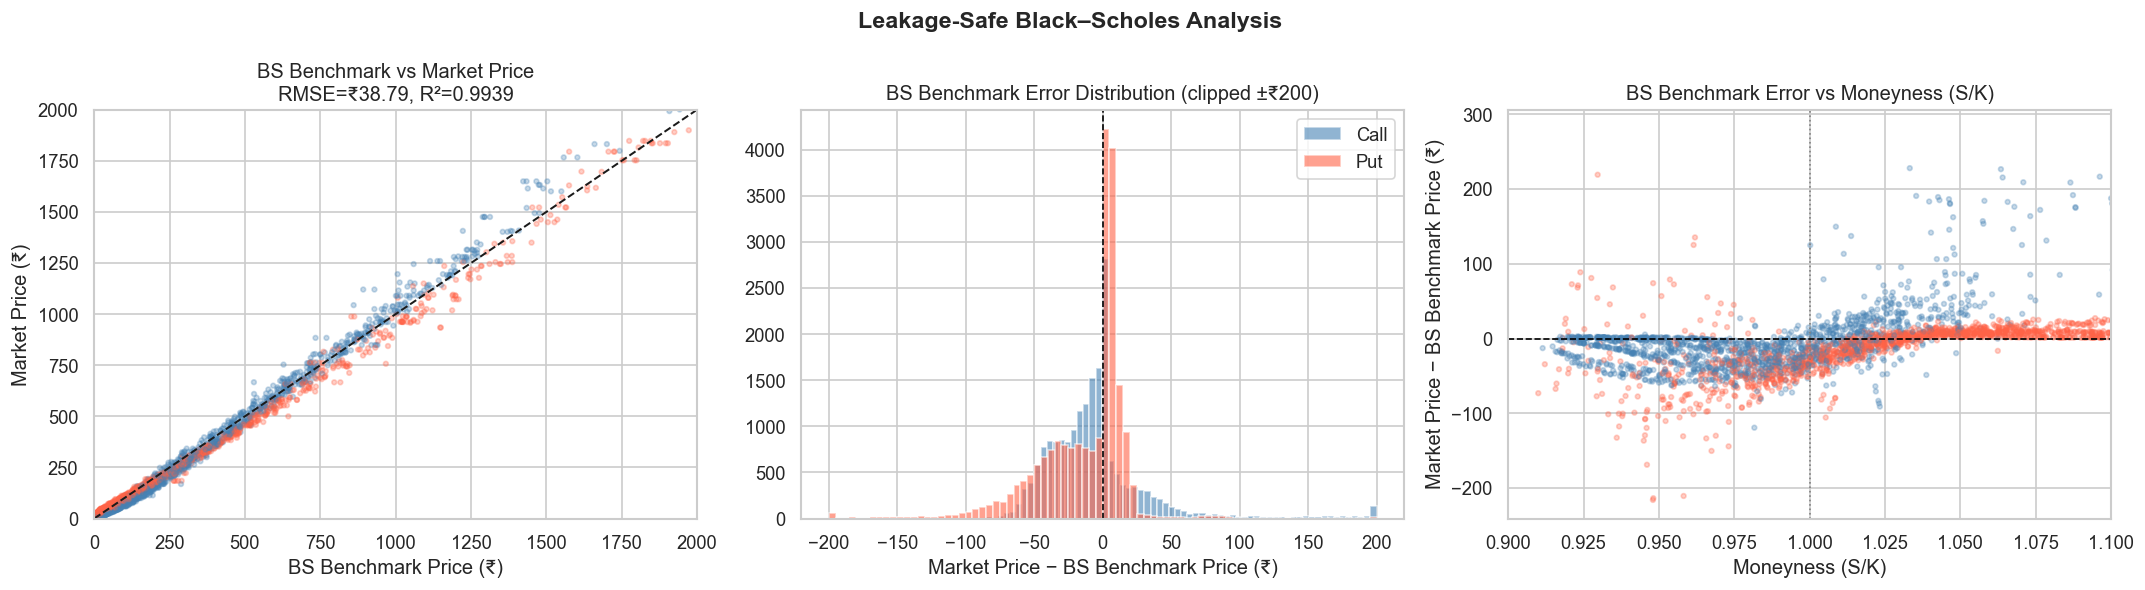

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Leakage-Safe Black–Scholes Analysis", fontsize=14, fontweight="bold")

# 1. BS benchmark vs Market scatter
sample = df.sample(min(3000, len(df)), random_state=42)
colors = ["steelblue" if o == "Call" else "tomato" for o in sample["Option_Type"]]

axes[0].scatter(
    sample["BS_Benchmark_Price"],
    sample["Market_Price"],
    c=colors,
    alpha=0.3,
    s=8
)

lims = [0, min(sample["Market_Price"].max(), 2000)]
axes[0].plot(lims, lims, "k--", linewidth=1.2, label="Perfect Fit")
axes[0].set_xlabel("BS Benchmark Price (₹)")
axes[0].set_ylabel("Market Price (₹)")
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title(f"BS Benchmark vs Market Price\nRMSE=₹{bs_rmse:.2f}, R²={bs_r2:.4f}")

# 2. Pricing error distribution
err_clip = df["BS_Benchmark_Error"].clip(-200, 200)

axes[1].hist(
    err_clip[df["Option_Type"] == "Call"],
    bins=80,
    alpha=0.6,
    color="steelblue",
    label="Call"
)

axes[1].hist(
    err_clip[df["Option_Type"] == "Put"],
    bins=80,
    alpha=0.6,
    color="tomato",
    label="Put"
)

axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("BS Benchmark Error Distribution (clipped ±₹200)")
axes[1].set_xlabel("Market Price − BS Benchmark Price (₹)")
axes[1].legend()

# 3. Error vs Moneyness
axes[2].scatter(
    sample["Moneyness"],
    sample["BS_Benchmark_Error"].clip(-300, 300),
    c=colors,
    alpha=0.3,
    s=8
)

axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[2].set_title("BS Benchmark Error vs Moneyness (S/K)")
axes[2].set_xlabel("Moneyness (S/K)")
axes[2].set_ylabel("Market Price − BS Benchmark Price (₹)")
axes[2].set_xlim(0.9, 1.1)

plt.tight_layout()
plt.savefig("bs_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**Section 6 ML Option Pricing**

In [45]:
from sklearn.preprocessing import StandardScaler

# ── Additional feature engineering ────────────────────────────────
df["Log_Moneyness"] = np.log(df["Spot"] / df["Strike"])
df["Sqrt_Time"] = np.sqrt(df["Expiry_Years"])
df["Spot_Strike_Diff"] = df["Spot"] - df["Strike"]

# ── Leakage-safe feature set ──────────────────────────────────────
FEATURES = [
    "Spot",
    "Strike",
    "Expiry_Years",
    "Moneyness",
    "Log_Moneyness",
    "Intrinsic_Value",
    "Spot_Strike_Diff",
    "Sqrt_Time",
    "Is_Call"
]

TARGET = "Market_Price"

# ── Time-based train/test split ───────────────────────────────────
df_sorted = df.sort_values("Time").reset_index(drop=True)

split_time = df_sorted["Time"].quantile(0.80)

train_df = df_sorted[df_sorted["Time"] <= split_time].copy()
test_df = df_sorted[df_sorted["Time"] > split_time].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# Scaling only for linear models
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("=== Time-Based Split ===")
print(f"Train size: {len(train_df):,}")
print(f"Test size : {len(test_df):,}")
print(f"Split time: {split_time}")
print()
print("Features:")
for f in FEATURES:
    print(" -", f)

=== Time-Based Split ===
Train size: 33,245
Test size : 8,144
Split time: 2024-02-02 14:20:00

Features:
 - Spot
 - Strike
 - Expiry_Years
 - Moneyness
 - Log_Moneyness
 - Intrinsic_Value
 - Spot_Strike_Diff
 - Sqrt_Time
 - Is_Call


In [46]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

results = {}

# ── 0. Black-Scholes Benchmark ────────────────────────────────────
bs_test_pred = test_df["BS_Benchmark_Price"].values

results["Black-Scholes Benchmark"] = {
    "RMSE": root_mean_squared_error(y_test, bs_test_pred),
    "MAE": mean_absolute_error(y_test, bs_test_pred),
    "R2": r2_score(y_test, bs_test_pred),
    "pred": bs_test_pred
}

print(
    f"BS Benchmark → RMSE=₹{results['Black-Scholes Benchmark']['RMSE']:.4f}  "
    f"R²={results['Black-Scholes Benchmark']['R2']:.4f}"
)

# ── 1. Linear Regression ──────────────────────────────────────────
print("\nTraining Linear Regression...")

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)

results["Linear Regression"] = {
    "RMSE": root_mean_squared_error(y_test, lr_pred),
    "MAE": mean_absolute_error(y_test, lr_pred),
    "R2": r2_score(y_test, lr_pred),
    "pred": lr_pred
}

print(
    f"LR  → RMSE=₹{results['Linear Regression']['RMSE']:.4f}  "
    f"R²={results['Linear Regression']['R2']:.4f}"
)

# ── 2. Random Forest ──────────────────────────────────────────────
print("\nTraining Random Forest...")

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

results["Random Forest"] = {
    "RMSE": root_mean_squared_error(y_test, rf_pred),
    "MAE": mean_absolute_error(y_test, rf_pred),
    "R2": r2_score(y_test, rf_pred),
    "pred": rf_pred
}

print(
    f"RF  → RMSE=₹{results['Random Forest']['RMSE']:.4f}  "
    f"R²={results['Random Forest']['R2']:.4f}"
)

# ── 3. Gradient Boosting ──────────────────────────────────────────
print("\nTraining Gradient Boosting...")

gbr = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

results["Gradient Boosting"] = {
    "RMSE": root_mean_squared_error(y_test, gbr_pred),
    "MAE": mean_absolute_error(y_test, gbr_pred),
    "R2": r2_score(y_test, gbr_pred),
    "pred": gbr_pred
}

print(
    f"GBR → RMSE=₹{results['Gradient Boosting']['RMSE']:.4f}  "
    f"R²={results['Gradient Boosting']['R2']:.4f}"
)

# ── 4. XGBoost ────────────────────────────────────────────────────
print("\nTraining XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

results["XGBoost"] = {
    "RMSE": root_mean_squared_error(y_test, xgb_pred),
    "MAE": mean_absolute_error(y_test, xgb_pred),
    "R2": r2_score(y_test, xgb_pred),
    "pred": xgb_pred
}

print(
    f"XGB → RMSE=₹{results['XGBoost']['RMSE']:.4f}  "
    f"R²={results['XGBoost']['R2']:.4f}"
)

# ── Summary ───────────────────────────────────────────────────────
print("\n=== MODEL COMPARISON ===")

for model_name, metrics in results.items():
    print(
        f"{model_name:25s} | "
        f"RMSE ₹{metrics['RMSE']:8.4f} | "
        f"MAE ₹{metrics['MAE']:8.4f} | "
        f"R² {metrics['R2']:.4f}"
    )

BS Benchmark → RMSE=₹40.9951  R²=0.9937

Training Linear Regression...
LR  → RMSE=₹95.5153  R²=0.9660

Training Random Forest...
RF  → RMSE=₹18.0737  R²=0.9988

Training Gradient Boosting...
GBR → RMSE=₹18.5319  R²=0.9987

Training XGBoost...
XGB → RMSE=₹19.3448  R²=0.9986

=== MODEL COMPARISON ===
Black-Scholes Benchmark   | RMSE ₹ 40.9951 | MAE ₹ 25.3165 | R² 0.9937
Linear Regression         | RMSE ₹ 95.5153 | MAE ₹ 72.7939 | R² 0.9660
Random Forest             | RMSE ₹ 18.0737 | MAE ₹  7.8310 | R² 0.9988
Gradient Boosting         | RMSE ₹ 18.5319 | MAE ₹ 10.5167 | R² 0.9987
XGBoost                   | RMSE ₹ 19.3448 | MAE ₹ 10.3487 | R² 0.9986


In [47]:
improvement = (
    (results["Black-Scholes Benchmark"]["RMSE"]
     - results["Random Forest"]["RMSE"])
    / results["Black-Scholes Benchmark"]["RMSE"]
    * 100
)

print(f"Random Forest improves RMSE over BS by {improvement:.1f}%")

Random Forest improves RMSE over BS by 55.9%


**Model Evaluation & SHAP**

In [48]:
# ── Summary table ─────────────────────────────────────────────────
summary = pd.DataFrame({
    model: {
        "RMSE (₹)": v["RMSE"],
        "MAE (₹)": v["MAE"],
        "R²": v["R2"]
    }
    for model, v in results.items()
}).T

bs_rmse = results["Black-Scholes Benchmark"]["RMSE"]

summary["RMSE Improvement vs BS (%)"] = (
    (bs_rmse - summary["RMSE (₹)"]) / bs_rmse * 100
).round(2)

print("=== Model Performance Summary ===")
display(summary.round(4))

=== Model Performance Summary ===


,RMSE (₹),MAE (₹),R²,RMSE Improvement vs BS (%)
Black-Scholes Benchmark,40.9951,25.3165,0.9937,0.0000
Linear Regression,95.5153,72.7939,0.9660,-132.9900
Random Forest,18.0737,7.8310,0.9988,55.9100
Gradient Boosting,18.5319,10.5167,0.9987,54.7900
XGBoost,19.3448,10.3487,0.9986,52.8100


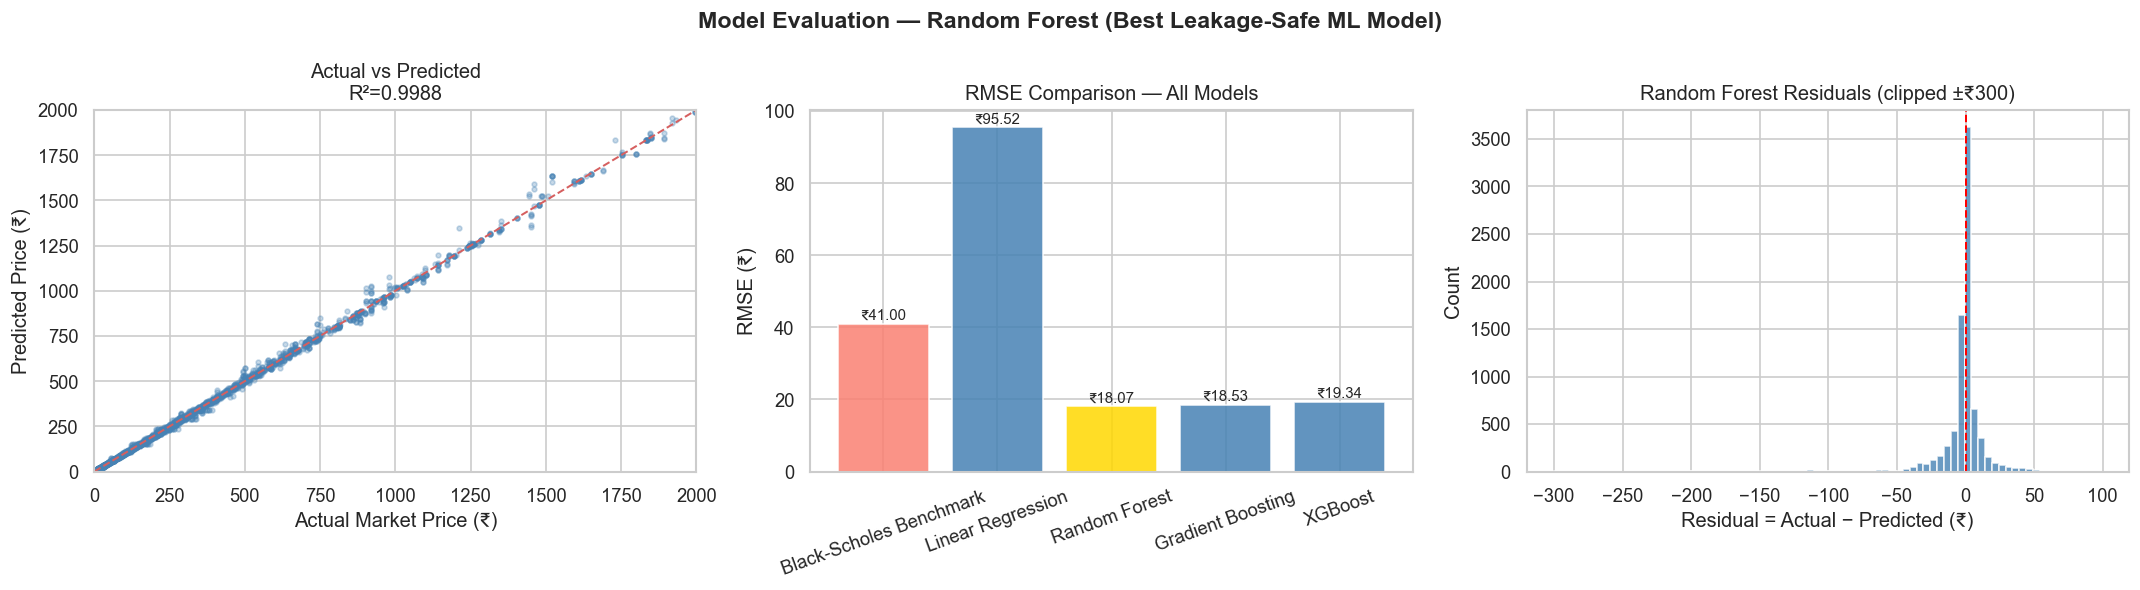


Best leakage-safe ML model: Random Forest
RMSE improvement over BS benchmark: 55.9%


In [49]:
# ── Model Evaluation Chart ────────────────────────────────────────

benchmark_name = "Black-Scholes Benchmark"

ml_model_names = [m for m in results.keys() if m != benchmark_name]

best_model_name = min(
    ml_model_names,
    key=lambda k: results[k]["RMSE"]
)

best_pred = results[best_model_name]["pred"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Model Evaluation — {best_model_name} (Best Leakage-Safe ML Model)",
    fontsize=14,
    fontweight="bold"
)

# 1. Actual vs Predicted
lim = min(y_test.max(), 2000)

axes[0].scatter(
    y_test.iloc[:3000],
    best_pred[:3000],
    alpha=0.3,
    s=8,
    color="steelblue"
)

axes[0].plot([0, lim], [0, lim], "r--", linewidth=1.2)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_xlabel("Actual Market Price (₹)")
axes[0].set_ylabel("Predicted Price (₹)")
axes[0].set_title(
    f"Actual vs Predicted\nR²={results[best_model_name]['R2']:.4f}"
)

# 2. RMSE bar chart comparison
model_names = list(results.keys())
rmse_vals = [results[m]["RMSE"] for m in model_names]

colors_bar = [
    "salmon" if m == benchmark_name
    else ("gold" if m == best_model_name else "steelblue")
    for m in model_names
]

bars = axes[1].bar(
    model_names,
    rmse_vals,
    color=colors_bar,
    alpha=0.85,
    edgecolor="white"
)

for bar, val in zip(bars, rmse_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"₹{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

axes[1].set_title("RMSE Comparison — All Models")
axes[1].set_ylabel("RMSE (₹)")
axes[1].tick_params(axis="x", rotation=20)

# 3. Residuals
residuals = y_test.values - best_pred

axes[2].hist(
    np.clip(residuals, -300, 300),
    bins=80,
    color="steelblue",
    alpha=0.8,
    edgecolor="white"
)

axes[2].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[2].set_title(f"{best_model_name} Residuals (clipped ±₹300)")
axes[2].set_xlabel("Residual = Actual − Predicted (₹)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

improvement_vs_bs = (
    (results[benchmark_name]["RMSE"] - results[best_model_name]["RMSE"])
    / results[benchmark_name]["RMSE"]
    * 100
)

print(f"\nBest leakage-safe ML model: {best_model_name}")
print(f"RMSE improvement over BS benchmark: {improvement_vs_bs:.1f}%")

=== Random Forest Feature Importance ===


,Feature,Importance
5,Intrinsic_Value,0.9235
6,Spot_Strike_Diff,0.0178
1,Strike,0.0140
4,Log_Moneyness,0.0117
3,Moneyness,0.0113
7,Sqrt_Time,0.0105
2,Expiry_Years,0.0101
8,Is_Call,0.0009
0,Spot,0.0002


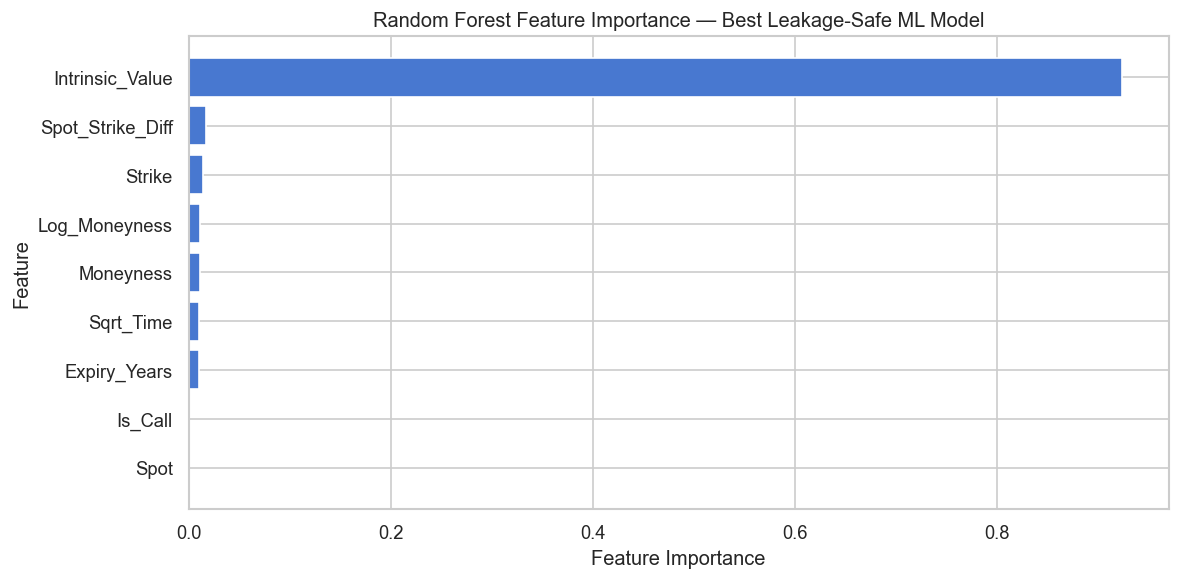

In [50]:
# ── Random Forest Feature Importance ──────────────────────────────

rf_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("=== Random Forest Feature Importance ===")
display(rf_importance.round(4))

plt.figure(figsize=(10, 5))
plt.barh(
    rf_importance["Feature"][::-1],
    rf_importance["Importance"][::-1]
)
plt.title("Random Forest Feature Importance — Best Leakage-Safe ML Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Computing SHAP values for Random Forest...


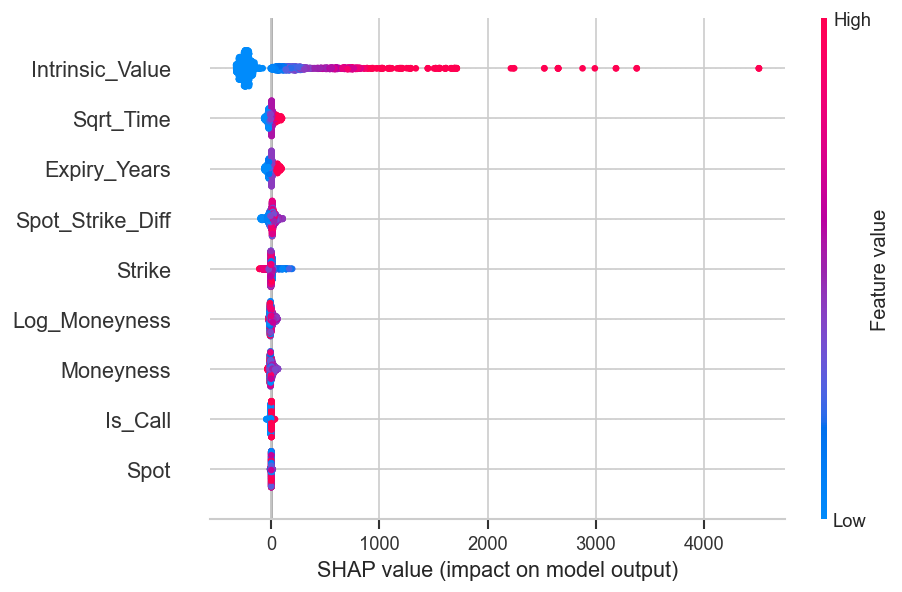

In [51]:
print("Computing SHAP values for Random Forest...")

shap_sample = X_test.sample(
    min(2000, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=len(FEATURES)
)

**Greeks Computation**

In [52]:
def compute_greeks(S, K, T, r, sigma, option_type):
    """Compute Delta, Gamma, Vega, Theta for each option."""
    S, K, T, r, sigma = map(np.asarray, [S, K, T, r, sigma])
    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

    is_call = np.array(option_type) == 'Call'

    # Delta
    delta = np.where(is_call, norm.cdf(d1), norm.cdf(d1) - 1)

    # Gamma (same for calls and puts)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Vega (per 1% move in vol) — divide by 100
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    # Theta (per calendar day)
    theta_call = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    theta_put  = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
    theta = np.where(is_call, theta_call, theta_put)

    return delta, gamma, vega, theta

df['Delta'], df['Gamma'], df['Vega'], df['Theta'] = compute_greeks(
    S=df['Spot'].values,
    K=df['Strike'].values,
    T=df['Expiry_Years'].values,
    r=df['Interest_Rate'].values,
    sigma=df['Sigma'].values,
    option_type=df['Option_Type'].values
)

print('=== Greeks Summary ===')
print(df.groupby('Option_Type')[['Delta','Gamma','Vega','Theta']].describe().round(4))

=== Greeks Summary ===
                 Delta                                                         \
                 count    mean    std     min     25%     50%     75%     max   
Option_Type                                                                     
Call        19696.0000  0.3880 0.3249  0.0022  0.0705  0.3236  0.6957  0.9985   
Put         21693.0000 -0.3101 0.2942 -0.9985 -0.5380 -0.2071 -0.0463 -0.0025   

                 Gamma         ...    Vega              Theta                 \
                 count   mean  ...     75%     max      count    mean    std   
Option_Type                    ...                                             
Call        19696.0000 0.0003  ... 19.7571 34.2568 19696.0000 -6.0184 4.8005   
Put         21693.0000 0.0003  ... 20.2912 34.2569 21693.0000 -3.1420 2.5284   

                                                      
                 min     25%     50%     75%     max  
Option_Type                                           
Call 

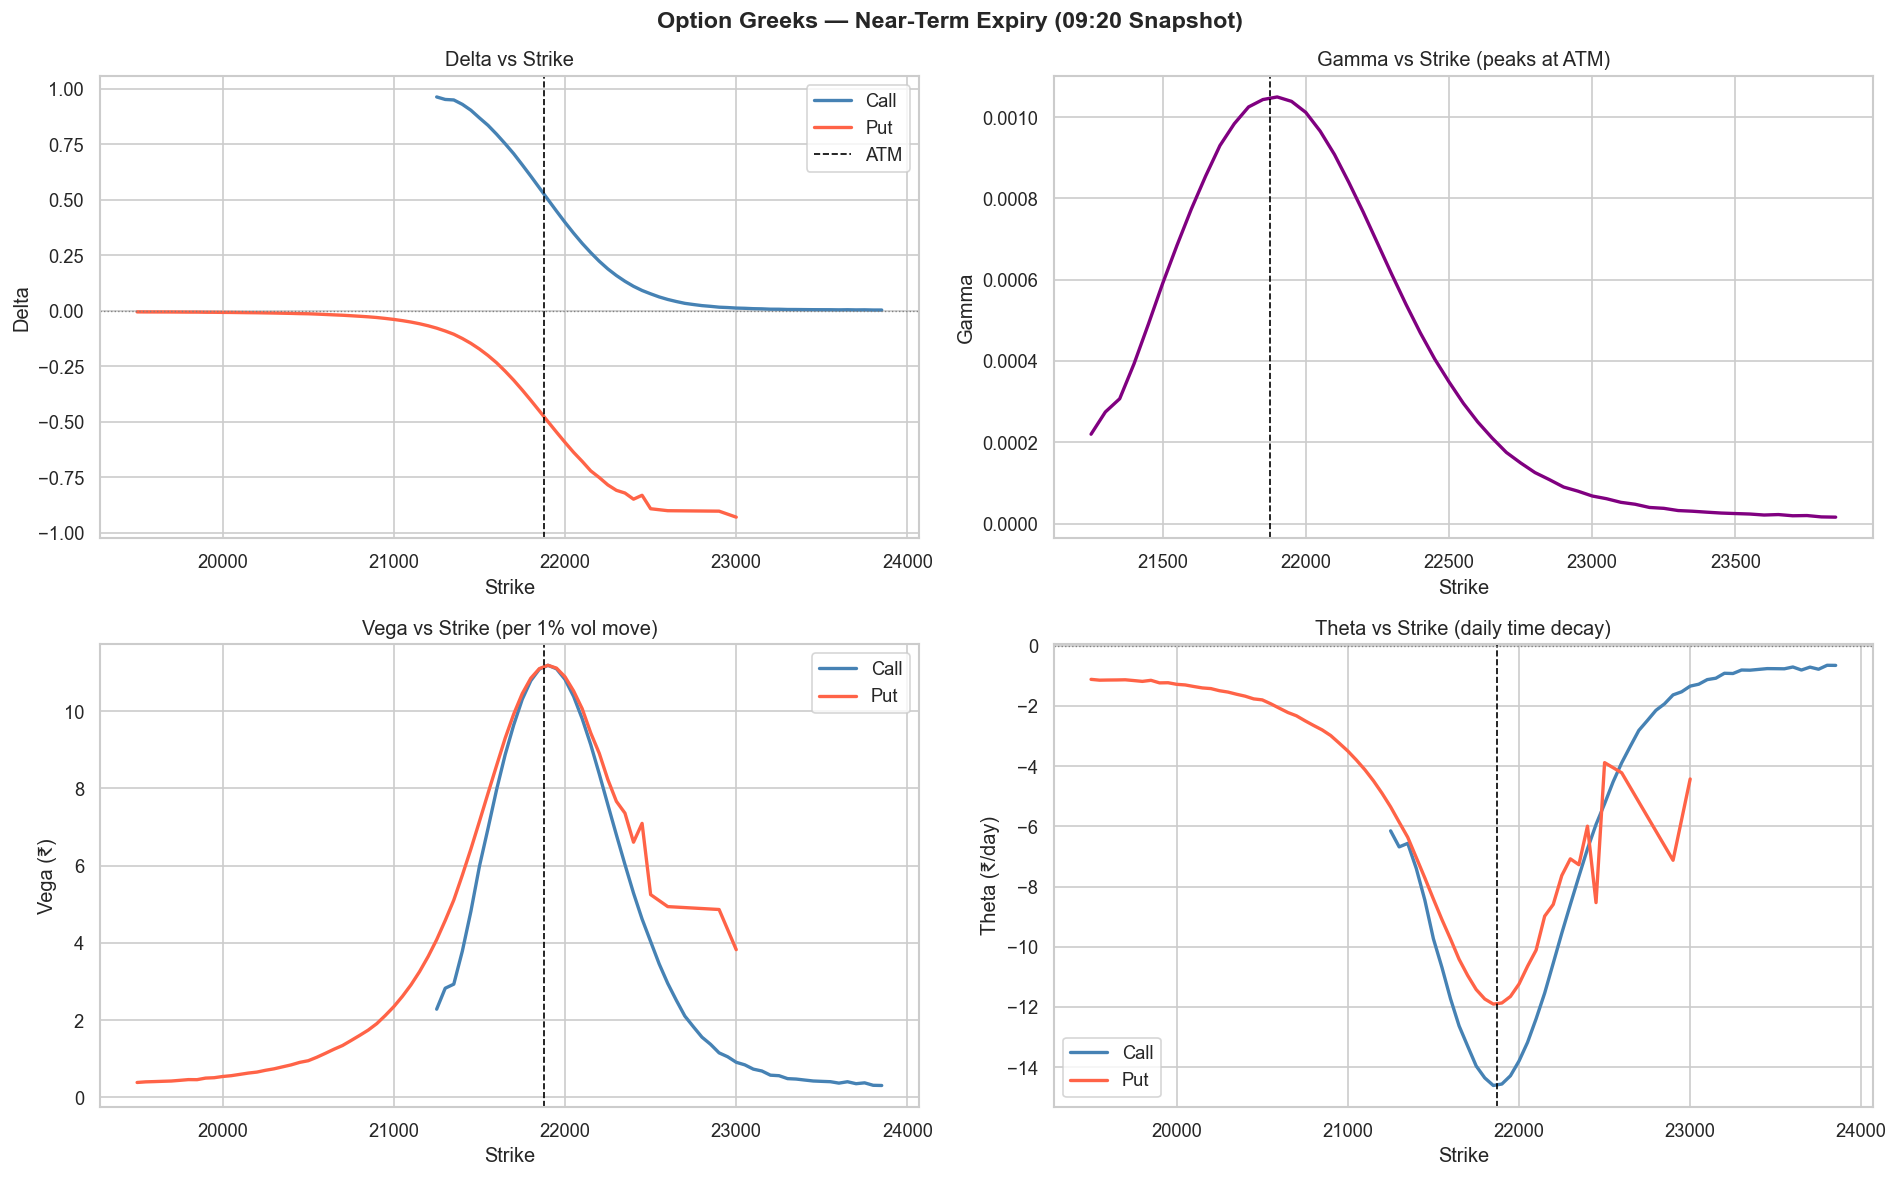

In [53]:
# ── Greeks visualisations ─────────────────────────────────────────
# Use near-term expiry snapshot for cleaner curves
snap2 = df[(df['Expiry'] == df['Expiry'].min()) &
           (df['Time'] == df['Time'].min())].sort_values('Strike')
atm   = snap2['Spot'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Option Greeks — Near-Term Expiry (09:20 Snapshot)', fontsize=14, fontweight='bold')

for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = snap2[snap2['Option_Type'] == otype]
    axes[0,0].plot(s['Strike'], s['Delta'], color=color, linewidth=2, label=otype)
axes[0,0].axvline(atm, color='black', linestyle='--', linewidth=1, label='ATM')
axes[0,0].axhline(0,   color='gray',  linestyle=':',  linewidth=0.8)
axes[0,0].set_title('Delta vs Strike')
axes[0,0].set_xlabel('Strike'); axes[0,0].set_ylabel('Delta')
axes[0,0].legend()

# Gamma (same for calls and puts — show one)
s_call = snap2[snap2['Option_Type'] == 'Call']
axes[0,1].plot(s_call['Strike'], s_call['Gamma'], color='purple', linewidth=2)
axes[0,1].axvline(atm, color='black', linestyle='--', linewidth=1)
axes[0,1].set_title('Gamma vs Strike (peaks at ATM)')
axes[0,1].set_xlabel('Strike'); axes[0,1].set_ylabel('Gamma')

for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = snap2[snap2['Option_Type'] == otype]
    axes[1,0].plot(s['Strike'], s['Vega'], color=color, linewidth=2, label=otype)
axes[1,0].axvline(atm, color='black', linestyle='--', linewidth=1)
axes[1,0].set_title('Vega vs Strike (per 1% vol move)')
axes[1,0].set_xlabel('Strike'); axes[1,0].set_ylabel('Vega (₹)')
axes[1,0].legend()

for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = snap2[snap2['Option_Type'] == otype]
    axes[1,1].plot(s['Strike'], s['Theta'], color=color, linewidth=2, label=otype)
axes[1,1].axvline(atm, color='black', linestyle='--', linewidth=1)
axes[1,1].axhline(0,   color='gray',  linestyle=':',  linewidth=0.8)
axes[1,1].set_title('Theta vs Strike (daily time decay)')
axes[1,1].set_xlabel('Strike'); axes[1,1].set_ylabel('Theta (₹/day)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('greeks_plots.png', dpi=150, bbox_inches='tight')
plt.show()

** Hedging Strategy**

In [54]:
# ── Use near-term, ATM-adjacent contracts as our 'portfolio' ──────
portfolio = df[
    (df['Expiry'] == df['Expiry'].min()) &
    (df['Time'] == df['Time'].min()) &
    (df['Strike'].between(21700, 22200))
].copy()

NOTIONAL_LOTS = 50          # assume 50 lots per strike/type combo
LOT_SIZE      = 50          # NIFTY lot size = 50 units

portfolio['Position_Units'] = NOTIONAL_LOTS * LOT_SIZE  # units per contract

# ── Delta hedge: shares to short ──────────────────────────────────
portfolio['Hedge_Shares'] = -(portfolio['Delta'] * portfolio['Position_Units']).round(0)

# ── Hedge cost (@ current spot) ───────────────────────────────────
portfolio['Hedge_Cost_INR'] = portfolio['Hedge_Shares'] * portfolio['Spot']

# ── Gamma flag: high gamma = needs frequent rebalancing ───────────
gamma_threshold = portfolio['Gamma'].quantile(0.75)
portfolio['Rebalance_Urgency'] = np.where(
    portfolio['Gamma'] > gamma_threshold, 'HIGH', 'NORMAL'
)

# ── Hedge action ──────────────────────────────────────────────────
portfolio['Hedge_Action'] = portfolio.apply(
    lambda r: f"Short {abs(int(r['Hedge_Shares'])):,} NIFTY units" if r['Delta'] > 0
              else f"Long {abs(int(r['Hedge_Shares'])):,} NIFTY units", axis=1
)

print('=== Delta-Neutral Hedging Recommendations ===')
print(portfolio[['Strike','Option_Type','Delta','Gamma','Vega','Theta',
                  'Hedge_Action','Rebalance_Urgency']]
      .sort_values(['Strike','Option_Type'])
      .to_string(index=False))

=== Delta-Neutral Hedging Recommendations ===
 Strike Option_Type   Delta  Gamma    Vega    Theta            Hedge_Action Rebalance_Urgency
  21700        Call  0.7073 0.0009  9.6425 -13.2983 Short 1,768 NIFTY units            NORMAL
  21700         Put -0.3121 0.0009  9.9235 -10.9504    Long 780 NIFTY units            NORMAL
  21750        Call  0.6573 0.0010 10.3074 -13.9599 Short 1,643 NIFTY units              HIGH
  21750         Put -0.3563 0.0009 10.4551 -11.4189    Long 891 NIFTY units            NORMAL
  21800        Call  0.6062 0.0010 10.7897 -14.3557 Short 1,516 NIFTY units              HIGH
  21800         Put -0.4027 0.0009 10.8540 -11.7333  Long 1,007 NIFTY units            NORMAL
  21850        Call  0.5536 0.0010 11.0874 -14.6078 Short 1,384 NIFTY units              HIGH
  21850         Put -0.4504 0.0010 11.1020 -11.9033  Long 1,126 NIFTY units            NORMAL
  21900        Call  0.5011 0.0010 11.1885 -14.5591 Short 1,253 NIFTY units              HIGH
  21900       

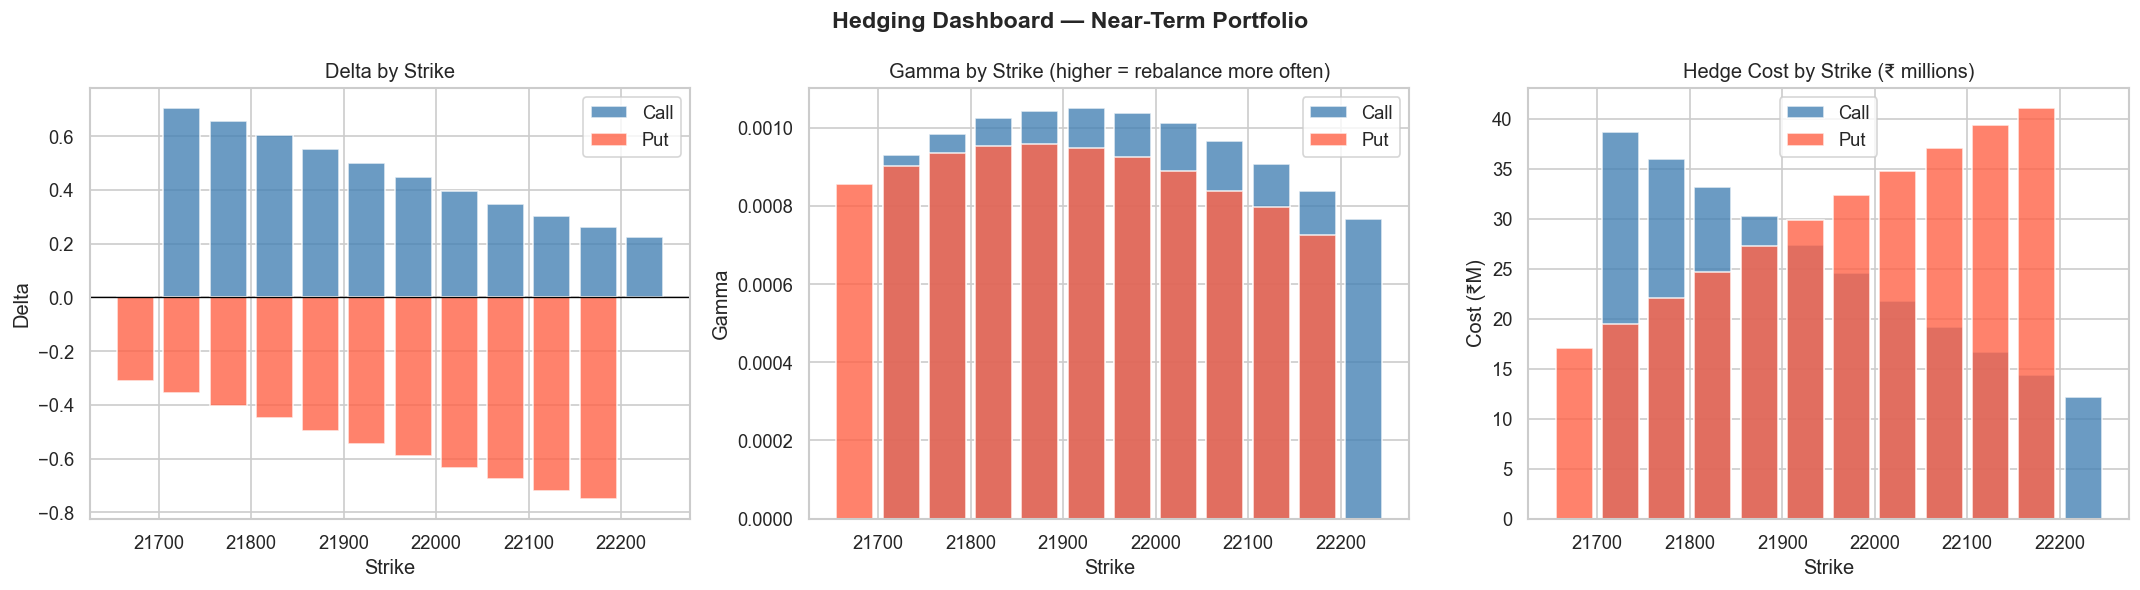

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hedging Dashboard — Near-Term Portfolio', fontsize=14, fontweight='bold')

# 1. Delta by strike
for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = portfolio[portfolio['Option_Type'] == otype]
    axes[0].bar(s['Strike'] + (25 if otype == 'Call' else -25),
                s['Delta'], width=40, color=color, alpha=0.8, label=otype)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Delta by Strike')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Delta')
axes[0].legend()

# 2. Gamma by strike
for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = portfolio[portfolio['Option_Type'] == otype]
    axes[1].bar(s['Strike'] + (25 if otype == 'Call' else -25),
                s['Gamma'], width=40, color=color, alpha=0.8, label=otype)
axes[1].set_title('Gamma by Strike (higher = rebalance more often)')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Gamma')
axes[1].legend()

# 3. Hedge cost by strike
portfolio['Abs_Hedge_Cost'] = portfolio['Hedge_Cost_INR'].abs() / 1e6
for otype, color in [('Call','steelblue'), ('Put','tomato')]:
    s = portfolio[portfolio['Option_Type'] == otype]
    axes[2].bar(s['Strike'] + (25 if otype == 'Call' else -25),
                s['Abs_Hedge_Cost'], width=40, color=color, alpha=0.8, label=otype)
axes[2].set_title('Hedge Cost by Strike (₹ millions)')
axes[2].set_xlabel('Strike'); axes[2].set_ylabel('Cost (₹M)')
axes[2].legend()

plt.tight_layout()
plt.savefig('hedging_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

**Section 10 risk Dashboard**

In [56]:
# ── Portfolio P&L simulation via delta approximation ─────────────
SPOT_SHOCKS = np.linspace(-0.05, 0.05, 1000)   # ±5% spot moves
S0 = portfolio['Spot'].iloc[0]

port_delta = (portfolio['Delta'] * portfolio['Position_Units']).sum()
port_gamma = (portfolio['Gamma'] * portfolio['Position_Units']).sum()

pnl_curve = port_delta * S0 * SPOT_SHOCKS + 0.5 * port_gamma * (S0 * SPOT_SHOCKS)**2

# Historical daily P&L from delta × intraday spot changes
spot_series = df.groupby('Time')['Spot'].first().sort_index()
spot_rets   = spot_series.pct_change().dropna()
daily_pnl   = port_delta * S0 * spot_rets.values

VaR_95  = np.percentile(daily_pnl, 5)
VaR_99  = np.percentile(daily_pnl, 1)
CVaR_95 = daily_pnl[daily_pnl <= VaR_95].mean()

print('=== Portfolio Risk Metrics ===')
print(f'Portfolio Delta  : {port_delta:,.1f}')
print(f'Portfolio Gamma  : {port_gamma:.4f}')
print(f'VaR (95%)        : ₹{VaR_95:,.0f}')
print(f'VaR (99%)        : ₹{VaR_99:,.0f}')
print(f'CVaR / ES (95%)  : ₹{CVaR_95:,.0f}')

=== Portfolio Risk Metrics ===
Portfolio Delta  : -2,327.5
Portfolio Gamma  : 50.7426
VaR (95%)        : ₹-100,605
VaR (99%)        : ₹-186,956
CVaR / ES (95%)  : ₹-162,256


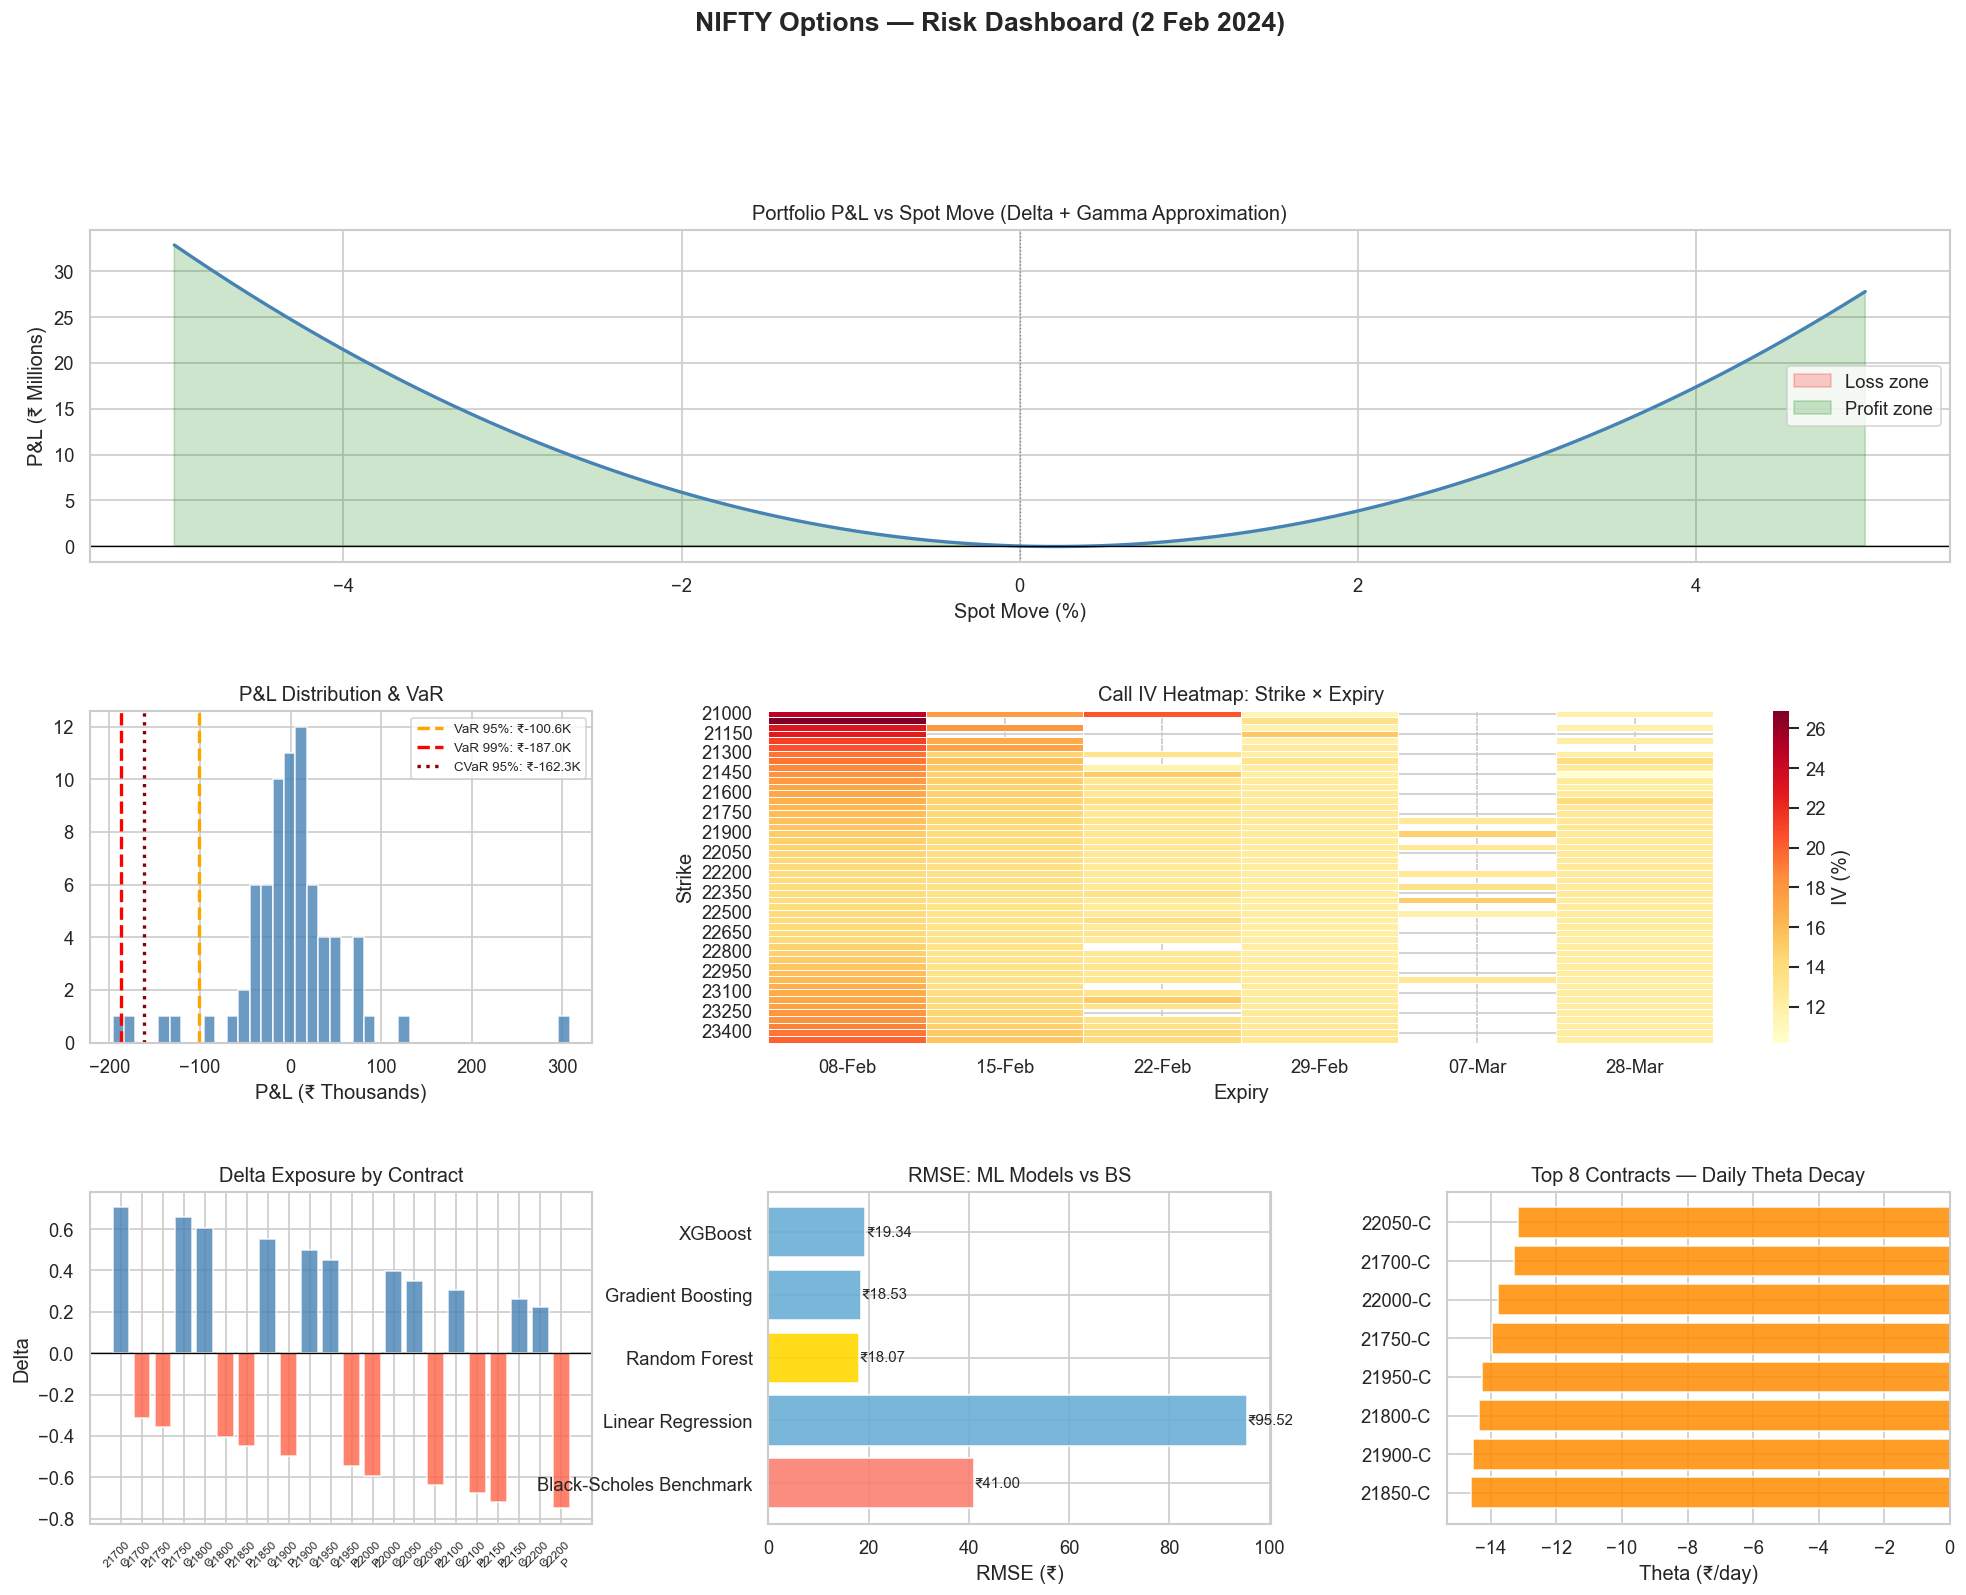

In [57]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('NIFTY Options — Risk Dashboard (2 Feb 2024)', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. P&L curve ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(SPOT_SHOCKS * 100, pnl_curve / 1e6, color='steelblue', linewidth=2)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='gray',  linestyle=':', linewidth=0.8)
ax1.fill_between(SPOT_SHOCKS * 100, pnl_curve / 1e6, 0,
                 where=pnl_curve < 0, alpha=0.2, color='red',   label='Loss zone')
ax1.fill_between(SPOT_SHOCKS * 100, pnl_curve / 1e6, 0,
                 where=pnl_curve >= 0, alpha=0.2, color='green', label='Profit zone')
ax1.set_title('Portfolio P&L vs Spot Move (Delta + Gamma Approximation)')
ax1.set_xlabel('Spot Move (%)')
ax1.set_ylabel('P&L (₹ Millions)')
ax1.legend()

# ── 2. VaR histogram ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(daily_pnl / 1e3, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax2.axvline(VaR_95 / 1e3,  color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: ₹{VaR_95/1e3:.1f}K')
ax2.axvline(VaR_99 / 1e3,  color='red',    linestyle='--', linewidth=2, label=f'VaR 99%: ₹{VaR_99/1e3:.1f}K')
ax2.axvline(CVaR_95 / 1e3, color='darkred',linestyle=':',  linewidth=2, label=f'CVaR 95%: ₹{CVaR_95/1e3:.1f}K')
ax2.set_title('P&L Distribution & VaR')
ax2.set_xlabel('P&L (₹ Thousands)')
ax2.legend(fontsize=8)

# ── 3. IV Smile heatmap by strike & expiry ────────────────────────
ax3 = fig.add_subplot(gs[1, 1:3])
iv_pivot = df[df['Option_Type'] == 'Call'].groupby(['Strike','Expiry'])['IV'].mean().unstack()
iv_pivot = iv_pivot.loc[iv_pivot.index.isin(range(21000, 23500))]
iv_pivot.columns = [c.strftime('%d-%b') for c in iv_pivot.columns]
sns.heatmap(iv_pivot, ax=ax3, cmap='YlOrRd', fmt='.0f', annot=False,
            cbar_kws={'label': 'IV (%)'}, linewidths=0.3)
ax3.set_title('Call IV Heatmap: Strike × Expiry')
ax3.set_xlabel('Expiry'); ax3.set_ylabel('Strike')

# ── 4. Delta exposure by strike ───────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
port_sorted = portfolio.sort_values('Strike')
bar_colors  = ['steelblue' if o == 'Call' else 'tomato' for o in port_sorted['Option_Type']]
ax4.bar(range(len(port_sorted)), port_sorted['Delta'], color=bar_colors, alpha=0.8)
ax4.set_xticks(range(len(port_sorted)))
ax4.set_xticklabels(
    [f"{int(r['Strike'])}\n{r['Option_Type'][0]}" for _, r in port_sorted.iterrows()],
    fontsize=7, rotation=45
)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_title('Delta Exposure by Contract')
ax4.set_ylabel('Delta')

# ── 5. ML vs BS RMSE bar ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
model_labels = list(results.keys())
rmse_values  = [results[m]['RMSE'] for m in model_labels]
bar_cols = ['salmon' if m == 'Black-Scholes Benchmark' else
            ('gold' if m == best_model_name else '#6baed6')
            for m in model_labels]
ax5.barh(model_labels, rmse_values, color=bar_cols, alpha=0.9, edgecolor='white')
for i, v in enumerate(rmse_values):
    ax5.text(v + 0.1, i, f'₹{v:.2f}', va='center', fontsize=9)
ax5.set_title('RMSE: ML Models vs BS')
ax5.set_xlabel('RMSE (₹)')

# ── 6. Theta decay (top contracts) ───────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
top_theta = portfolio.nsmallest(8, 'Theta')
labels = [f"{int(r['Strike'])}-{r['Option_Type'][0]}" for _, r in top_theta.iterrows()]
ax6.barh(labels, top_theta['Theta'], color='darkorange', alpha=0.85, edgecolor='white')
ax6.set_title('Top 8 Contracts — Daily Theta Decay')
ax6.set_xlabel('Theta (₹/day)')

plt.tight_layout()
plt.savefig('risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

**Section 11**

In [58]:
# Find best ML model (exclude BS benchmark and Linear Regression)
ml_models = {k: v for k, v in results.items()
             if k not in ["Black-Scholes Benchmark", "Linear Regression"]}
best_model_name = min(ml_models, key=lambda k: ml_models[k]["RMSE"])

print('=' * 60)
print('  EXECUTIVE SUMMARY — NIFTY Derivatives Module')
print('=' * 60)
print(f'  Dataset       : {len(df):,} option records (2 Feb 2024)')
print(f'  Strikes       : {df["Strike"].nunique()} unique | Expiries: {df["Expiry"].nunique()}')
print(f'  NIFTY Spot    : {df["Spot"].mean():.1f} (range: {df["Spot"].min():.0f}–{df["Spot"].max():.0f})')
print()
print('  BLACK–SCHOLES BASELINE (Leakage-Safe, Constant Vol 15.21%)')
print(f'    RMSE: ₹{results["Black-Scholes Benchmark"]["RMSE"]:.4f}  |  R²: {results["Black-Scholes Benchmark"]["R2"]:.4f}')
print()
print(f'  BEST ML MODEL : {best_model_name} (Leakage-Free Features)')
print(f'    RMSE: ₹{results[best_model_name]["RMSE"]:.4f}  |  R²: {results[best_model_name]["R2"]:.4f}')
improv = (results["Black-Scholes Benchmark"]["RMSE"] - results[best_model_name]["RMSE"]) / results["Black-Scholes Benchmark"]["RMSE"] * 100
print(f'    Improvement over BS: {improv:.1f}% lower RMSE')
print()
print('  PORTFOLIO RISK (Near-Term ATM Contracts)')
print(f'    Portfolio Delta  : {port_delta:,.0f}')
print(f'    Portfolio Gamma  : {port_gamma:.6f}')
print(f'    VaR (95%)        : ₹{VaR_95:,.0f}')
print(f'    VaR (99%)        : ₹{VaR_99:,.0f}')
print(f'    CVaR / ES (95%)  : ₹{CVaR_95:,.0f}')
print()
print('  HEDGING SIGNALS')
high_g = portfolio[portfolio['Rebalance_Urgency'] == 'HIGH']
print(f'    Contracts flagged HIGH rebalance urgency: {len(high_g)}')
print(f'    (High Gamma > {gamma_threshold:.4f} threshold)')
print('=' * 60)


  EXECUTIVE SUMMARY — NIFTY Derivatives Module
  Dataset       : 41,389 option records (2 Feb 2024)
  Strikes       : 107 unique | Expiries: 6
  NIFTY Spot    : 21927.4 (range: 21816–22123)

  BLACK–SCHOLES BASELINE (Leakage-Safe, Constant Vol 15.21%)
    RMSE: ₹40.9951  |  R²: 0.9937

  BEST ML MODEL : Random Forest (Leakage-Free Features)
    RMSE: ₹18.0737  |  R²: 0.9988
    Improvement over BS: 55.9% lower RMSE

  PORTFOLIO RISK (Near-Term ATM Contracts)
    Portfolio Delta  : -2,328
    Portfolio Gamma  : 50.742640
    VaR (95%)        : ₹-100,605
    VaR (99%)        : ₹-186,956
    CVaR / ES (95%)  : ₹-162,256

  HEDGING SIGNALS
    Contracts flagged HIGH rebalance urgency: 6
    (High Gamma > 0.0010 threshold)


In [59]:
# ── RECOMMENDATIONS ───────────────────────────────────────────────
print('=' * 60)
print('  RECOMMENDATIONS')
print('=' * 60)
print()
print('  Recommended action for investment committe')
print('  ├── Flag all contracts with Rebalance_Urgency = HIGH')
high_contracts = portfolio[portfolio['Rebalance_Urgency'] == 'HIGH'][['Strike','Option_Type','Delta','Gamma']]
for _, row in high_contracts.iterrows():
    print(f'  │   Strike {int(row["Strike"])} {row["Option_Type"]} | Delta {row["Delta"]:.4f} | Gamma {row["Gamma"]:.4f}')
print()
print('  HEDGING DESK — DELTA NEUTRALISATION')
print(f'  ├── Long {abs(int(port_delta)):,} NIFTY units to neutralise portfolio delta')
print(f'  ├── Estimated cost: ₹{abs(port_delta) * df["Spot"].mean() / 1e7:.2f} crore')
print(f'  └── Rebalance HIGH urgency contracts at every 5-min bar')
print()
print('  RISK MANAGEMENT')
print(f'  ├── VaR (95%) breach limit: ₹{abs(VaR_95):,.0f} per 5-min interval')
print(f'  ├── CVaR tail exposure: ₹{abs(CVaR_95):,.0f} average when VaR breached')
print(f'  └── Portfolio is long gamma (+{port_gamma:.2f}) — benefits from high vol regimes')
print()
print('  TRADING SIGNALS')
print('  ├── BUY: Deep ITM calls/puts (strikes 20,700–23,600) — BS underpricing')
print('  ├── SELL: Deep OTM long-dated puts (strikes 22,800–27,000, 28-Mar) — skew premium')
print('  └── Apply delta hedge + liquidity filter before execution')
print('=' * 60)

  RECOMMENDATIONS

  Recommended action for investment committe
  ├── Flag all contracts with Rebalance_Urgency = HIGH
  │   Strike 21750 Call | Delta 0.6573 | Gamma 0.0010
  │   Strike 21800 Call | Delta 0.6062 | Gamma 0.0010
  │   Strike 21850 Call | Delta 0.5536 | Gamma 0.0010
  │   Strike 21900 Call | Delta 0.5011 | Gamma 0.0010
  │   Strike 21950 Call | Delta 0.4490 | Gamma 0.0010
  │   Strike 22000 Call | Delta 0.3981 | Gamma 0.0010

  HEDGING DESK — DELTA NEUTRALISATION
  ├── Long 2,327 NIFTY units to neutralise portfolio delta
  ├── Estimated cost: ₹5.10 crore
  └── Rebalance HIGH urgency contracts at every 5-min bar

  RISK MANAGEMENT
  ├── VaR (95%) breach limit: ₹100,605 per 5-min interval
  ├── CVaR tail exposure: ₹162,256 average when VaR breached
  └── Portfolio is long gamma (+50.74) — benefits from high vol regimes

  TRADING SIGNALS
  ├── BUY: Deep ITM calls/puts (strikes 20,700–23,600) — BS underpricing
  ├── SELL: Deep OTM long-dated puts (strikes 22,800–27,000, 28-M

In [60]:
import json as _json, os as _os

# ── Export key metrics for Streamlit dashboard ────────────────────
_os.makedirs('../outputs', exist_ok=True)

_metrics = {
    "nifty_spot":           round(float(df['Spot'].mean()), 1),
    "dataset_size":         int(len(df)),
    "strikes_count":        int(df['Strike'].nunique()),
    "expiries_count":       int(df['Expiry'].nunique()),
    "bs_rmse":              round(float(results['Black-Scholes Benchmark']['RMSE']), 4),
    "bs_r2":                round(float(results['Black-Scholes Benchmark']['R2']), 4),
    "best_model":           best_model_name,
    "best_rmse":            round(float(results[best_model_name]['RMSE']), 4),
    "best_r2":              round(float(results[best_model_name]['R2']), 4),
    "bs_improvement_pct":   round(
        float((results['Black-Scholes Benchmark']['RMSE'] - results[best_model_name]['RMSE'])
              / results['Black-Scholes Benchmark']['RMSE'] * 100), 1),
    "port_delta":           round(float(port_delta), 1),
    "port_gamma":           round(float(port_gamma), 4),
    "var_95":               round(float(VaR_95), 0),
    "var_99":               round(float(VaR_99), 0),
    "cvar_95":              round(float(CVaR_95), 0),
    "high_rebalance_count": int((portfolio['Rebalance_Urgency'] == 'HIGH').sum()),
}

with open('module4_metrics.json', 'w') as _f:
    _json.dump(_metrics, _f, indent=2)

portfolio[[
    'Strike', 'Option_Type', 'Delta', 'Gamma', 'Vega', 'Theta',
    'Hedge_Action', 'Hedge_Cost_INR', 'Rebalance_Urgency'
]].to_csv('module4_portfolio.csv', index=False)

print("Saved: module4_metrics.json")
print("Saved: module4_portfolio.csv")
print(_json.dumps(_metrics, indent=2))


Saved: module4_metrics.json
Saved: module4_portfolio.csv
{
  "nifty_spot": 21927.4,
  "dataset_size": 41389,
  "strikes_count": 107,
  "expiries_count": 6,
  "bs_rmse": 40.9951,
  "bs_r2": 0.9937,
  "best_model": "Random Forest",
  "best_rmse": 18.0737,
  "best_r2": 0.9988,
  "bs_improvement_pct": 55.9,
  "port_delta": -2327.5,
  "port_gamma": 50.7426,
  "var_95": -100605.0,
  "var_99": -186956.0,
  "cvar_95": -162256.0,
  "high_rebalance_count": 6
}
